# Building Explainable Machine Learning Models
Explaining models with LIME

LIME stands for Local Interpretable Model-Agnostic Explanations)
It generates an explanation by approximating the underlying model by an interpretable one.


Throughout this notebook,  you are going to be using LIME by working on the adult income dataset. You'll perform the following steps:

1. Import and preprocess the dataset
2. Train a Random Forest classifier on the data.
3. Explain individualised explanations using LIME


Let's get started!

---

## Case Study

### Predicting if income exceeds $50,000 per year based on 1994 US Census Data

 The Adult Income dataset, also known as the "Census Income" dataset, contains a variety of attributes or features that describe individuals in the dataset. The target variable is True if a person earns more than `$50K` annually and False if the earned income is ≤ $50K. The attributes of our dataset (preprocessed version) include:

* **Age** : the age of the individual
* **Workclass** : the type of employment the individual has (e.g. private, government, self-employed)
* **Education** : the level of education the individual has achieved (e.g. high school, college, graduate degree)
* **Marital-status** : the individual's marital status (e.g. married, divorced, single)
* **Occupation** : the type of work the individual is employed in (e.g. sales, management, craft-repair)
* **Race** : the individual's race (e.g. White, Black, Asian)
* **Sex** : the individual's gender (e.g. Male, Female)
* **Hours-per-week** : the number of hours the individual works per week
* **Income** : the individual's income level (either <=50K or >50K)


<div class="alert alert-block alert-danger">


Note that the attributes might be different based on the source of the dataset and the version you are using.Also this dataset reflects bias and imbalance w.r.t gender and race. Be careful when using such datasets. In this notebook this dataset is only used for demo purposes.

---

# Importing Necessary Libraries

Let’s start by importing the necessary libraries.

In [6]:
#%pip install lime -qq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(123) #ensure reproducibility

import warnings
warnings.filterwarnings("ignore")
np.random.seed(123) #ensure reproducibility
RANDOM_STATE = 42

## Model Interpretation package
import lime
from lime import lime_tabular


import warnings
warnings.filterwarnings("ignore")

In [7]:
# setting up the styling for the plots in this notebook
sns.set(style="white", palette="colorblind", font_scale=1.2,
        rc={"figure.figsize":(10,6)})

# Reading in the Dataset

In [8]:
data= pd.read_csv(r'C:\Users\User\Desktop\Data-Science-Class\Data\Adult Income Dataset.csv')
data.head()

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,28,Private,Bachelors,Single,White-Collar,White,Female,60,0
1,30,Self-Employed,Assoc,Married,Professional,White,Male,65,1
2,32,Private,Some-college,Married,White-Collar,White,Male,50,0
3,20,Private,Some-college,Single,Service,White,Female,35,0
4,41,Self-Employed,Some-college,Married,White-Collar,White,Male,50,0


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26048 entries, 0 to 26047
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             26048 non-null  int64
 1   workclass       26048 non-null  str  
 2   education       26048 non-null  str  
 3   marital_status  26048 non-null  str  
 4   occupation      26048 non-null  str  
 5   race            26048 non-null  str  
 6   gender          26048 non-null  str  
 7   hours_per_week  26048 non-null  int64
 8   income          26048 non-null  int64
dtypes: int64(3), str(6)
memory usage: 1.8 MB


In [10]:
# Inspecting Distribution of Target Variable

data['income'].value_counts()

income
0    19820
1     6228
Name: count, dtype: int64

# Data Preparation

## Train/Test Split
Splitting the dataset into traininga and validation dataset.

In [11]:
# Creating the target and the features column and splitting the dataset into test and train set.

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# splitting the dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)



## Encoding the categorical features

We'll leave the numerical features as-is and only encode the categorical features using a OrdinalEncoder.

In [12]:
numerical_features = [
    "age",
    "hours_per_week"]

categorical_features = X_train.columns.drop(numerical_features)
categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation', 'race',
       'gender'],
      dtype='str')

In [13]:
encoder = OrdinalEncoder()
X_train_categorical_data = X_train[categorical_features]
X_train_encoded = encoder.fit_transform(X_train_categorical_data)

In [14]:
encoder.categories_

[array(['Government', 'Other/Unknown', 'Private', 'Self-Employed'],
       dtype=object),
 array(['Assoc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters',
        'Prof-school', 'School', 'Some-college'], dtype=object),
 array(['Divorced', 'Married', 'Separated', 'Single', 'Widowed'],
       dtype=object),
 array(['Blue-Collar', 'Other/Unknown', 'Professional', 'Sales', 'Service',
        'White-Collar'], dtype=object),
 array(['Other', 'White'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [15]:
class_names =  np.array([0,1])

## Preprocessed Training Set

In [16]:
X_train_encoded_df = pd.DataFrame(X_train_encoded,columns = categorical_features, index = X_train.index)
X_train_preprocessed = pd.concat([X_train_encoded_df,X_train[numerical_features]],axis=1)
X_train_preprocessed

,workclass,education,marital_status,occupation,race,gender,age,hours_per_week
9184,2.0,7.0,3.0,5.0,0.0,0.0,24,25
448,2.0,3.0,1.0,0.0,1.0,1.0,39,40
9013,2.0,7.0,1.0,5.0,0.0,0.0,24,45
14986,2.0,6.0,3.0,4.0,1.0,0.0,22,30
25531,2.0,1.0,3.0,2.0,1.0,1.0,30,50
...,...,...,...,...,...,...,...,...
13123,3.0,0.0,3.0,0.0,1.0,1.0,34,40
19648,2.0,1.0,3.0,2.0,1.0,1.0,37,40
9845,2.0,7.0,3.0,5.0,1.0,0.0,19,16
10799,2.0,3.0,1.0,0.0,1.0,1.0,29,45


## Preprocessing the test set

In [17]:

X_test_categorical_data = X_test[categorical_features]
X_test_encoded = encoder.transform(X_test_categorical_data)
X_test_encoded_df = pd.DataFrame(X_test_encoded,columns = categorical_features,index = X_test.index)
X_test_preprocessed = pd.concat([X_test_encoded_df,X_test[numerical_features]],axis=1)
X_test_preprocessed.head()



,workclass,education,marital_status,occupation,race,gender,age,hours_per_week
8771,2.0,7.0,3.0,0.0,1.0,1.0,22,25
13138,3.0,7.0,1.0,5.0,1.0,1.0,50,50
15380,2.0,7.0,3.0,0.0,1.0,0.0,22,30
15502,2.0,6.0,1.0,2.0,0.0,1.0,63,30
16555,2.0,6.0,0.0,0.0,1.0,1.0,31,40


## Building a Decision Tree Clasifier to explain how the model Splits to arrive to the leaf Node

In [18]:
model = DecisionTreeClassifier(max_depth=6, random_state=0)
model.fit(X_train_preprocessed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

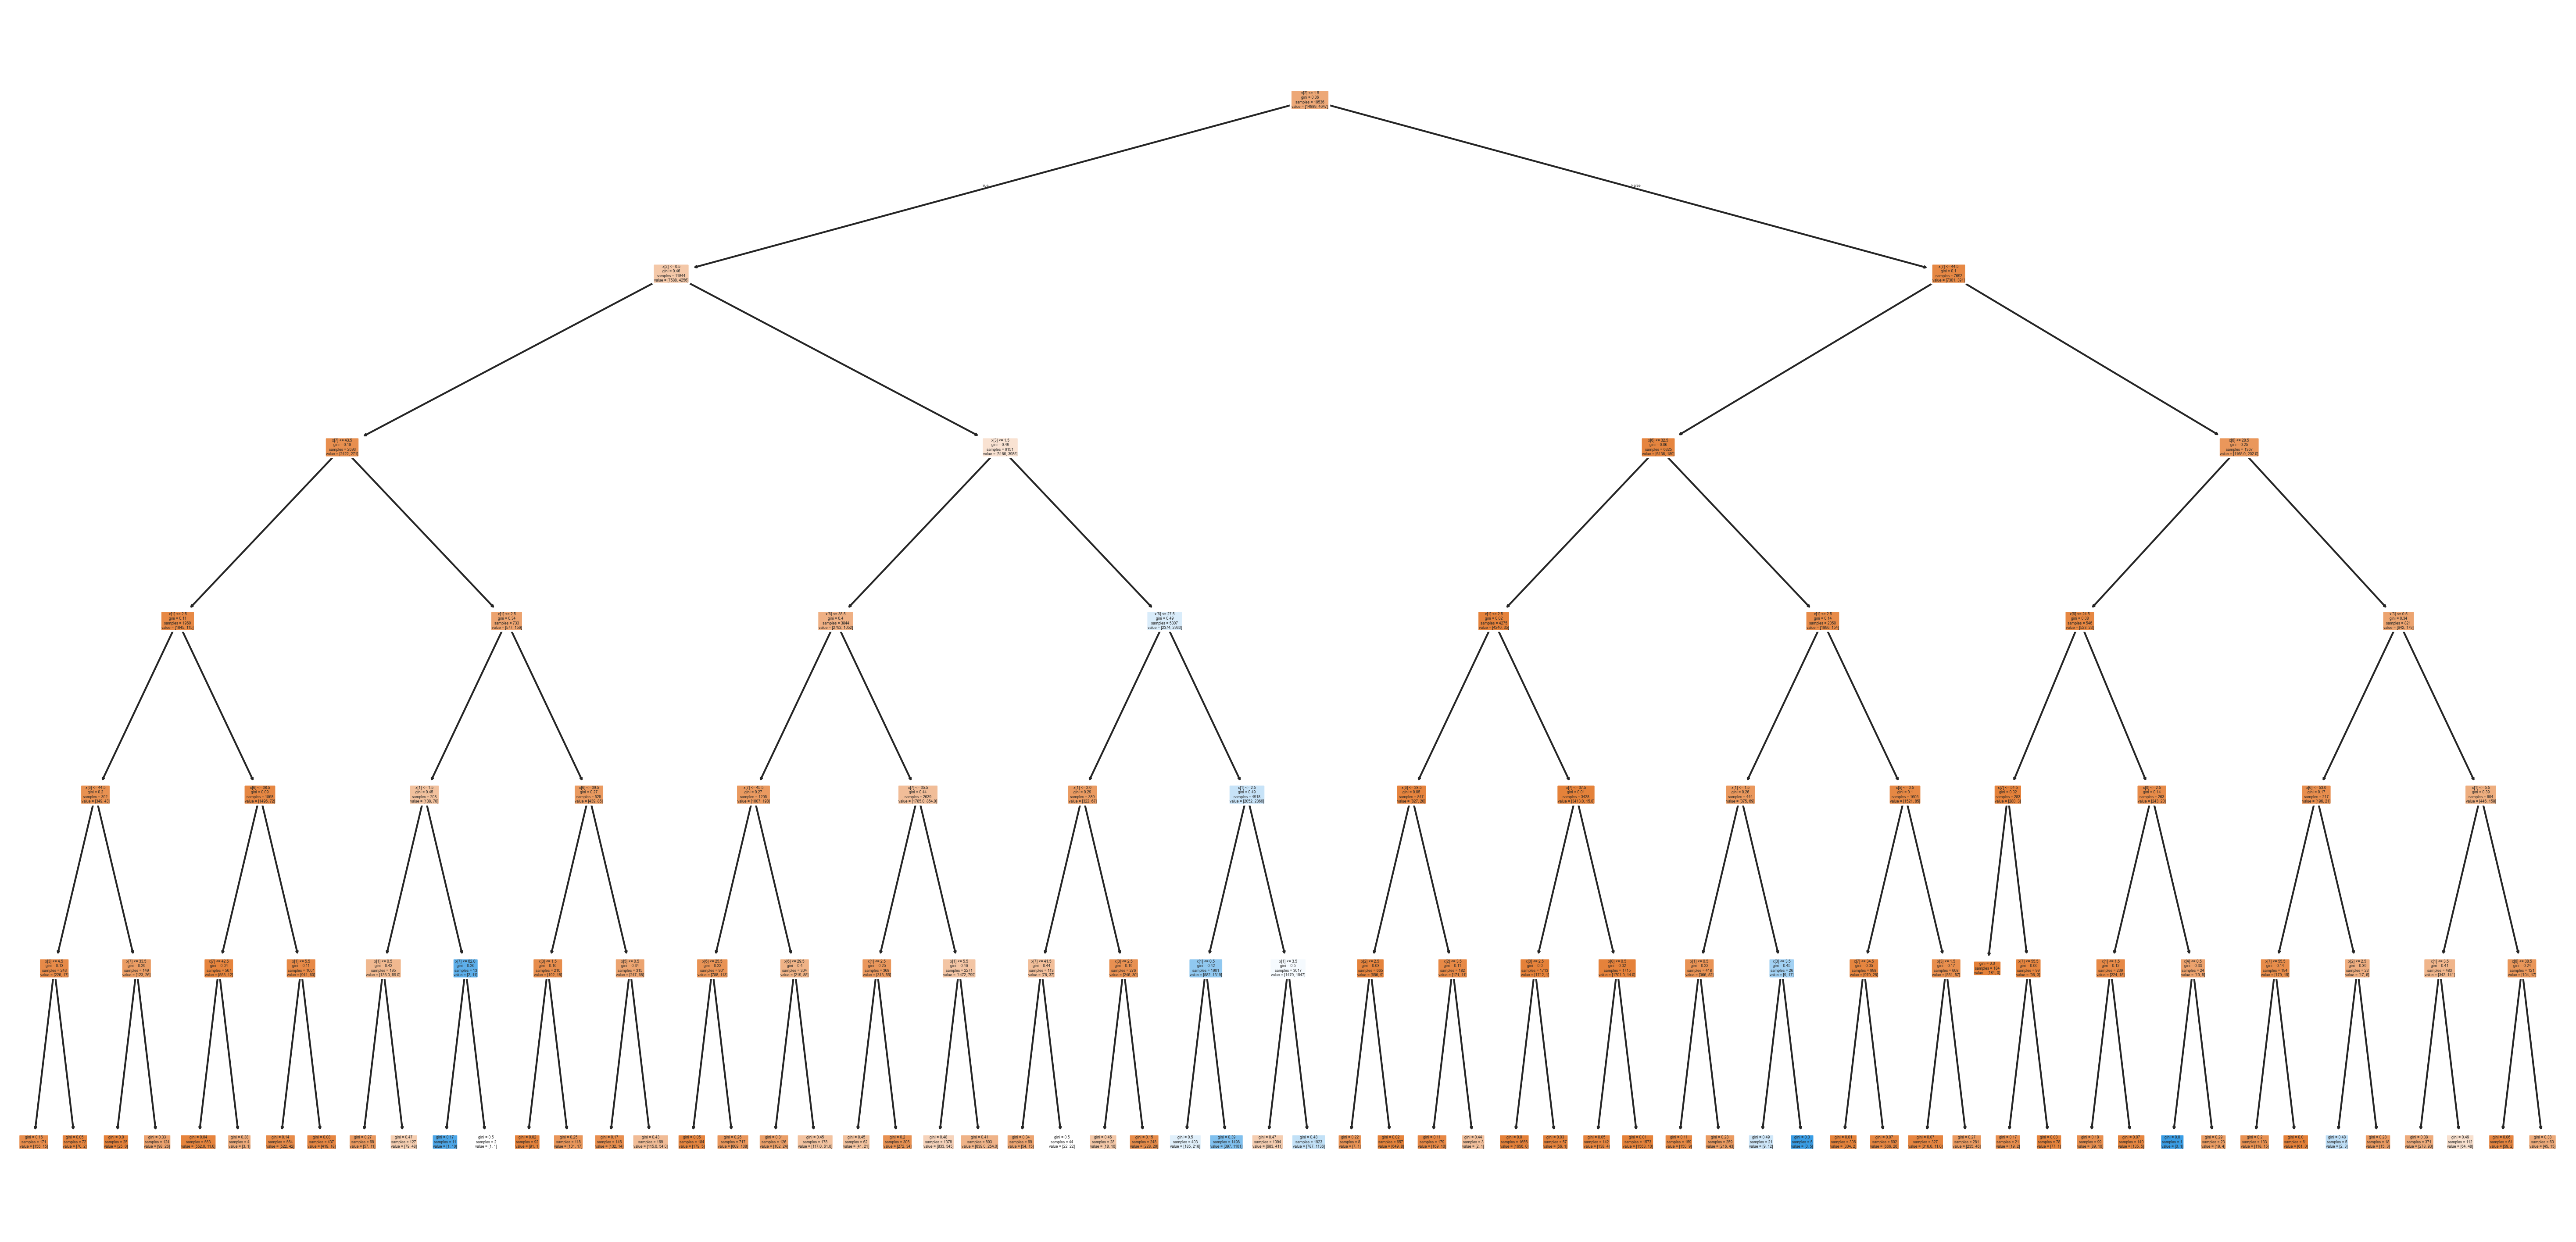

In [22]:
plt.figure(figsize=(25,12), dpi = 300)
plot_tree(model, 
          filled=True, 
          rounded=True, 
          precision = 2);

plt.show()

# Training the classifier


Now you will fit a [Random Forest classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and compute the [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html) achieved:

In [13]:
model = RandomForestClassifier(max_depth=6, random_state=0, n_estimators=20)
model.fit(X_train_preprocessed, y_train)

RandomForestClassifier(max_depth=6, n_estimators=20, random_state=0)

In [14]:
model.score(X_test_preprocessed, y_test)

0.8115786240786241

In [15]:
# Making predictions on the test set
y_pred = model.predict_proba(X_test_preprocessed)[:, 1]

## Displaying Random Forests' Feature Importance

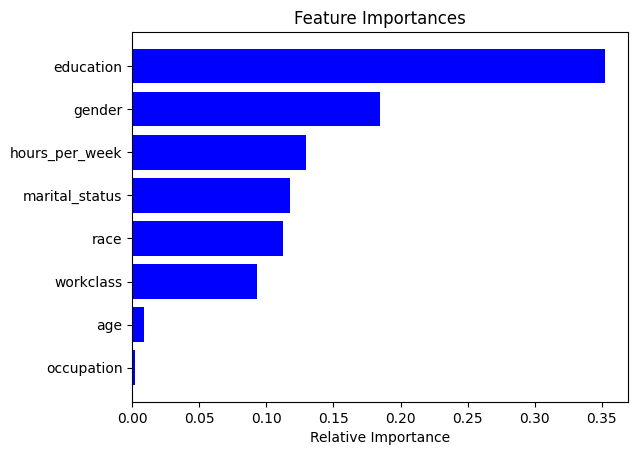

In [16]:
importances = model.feature_importances_
indices = np.argsort(importances)
features = X_train.columns
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

---

# Explaining predicitions with LIME Tabular
As our dataset is tabular, we create an instance of LimeTabularExplainer().

* training_data: Pass the dataset,
* mode: can be regression or classification. We are working on a classification problem, so we set the mode parameter to “classification.”
* feature_names: All the input features in the dataset, used for computing statistics on each feature. Mean, and the standard deviation is computed for numerical feature whereas categorical features are discretized it into quantiles.
* training_labels: pass the training target variable

In [17]:
explainer= lime.lime_tabular.LimeTabularExplainer(training_data=np.array(X_test_preprocessed),
                                mode='classification',
                                feature_names=list(X_test_preprocessed.columns),
                                training_labels=np.array(y_test),
                                kernel_width=3,
                                random_state=RANDOM_STATE)

In [18]:
explainer

In [19]:
X_test_preprocessed.columns

Index(['workclass', 'education', 'marital_status', 'occupation', 'race',
       'gender', 'age', 'hours_per_week'],
      dtype='object')

## Explaining a single prediction
Let's obtain the explanations from LIME for particular values in the validation dataset.

In [ ]:
i=1
exp = explainer.explain_instance(X_test_preprocessed.iloc[i], model.predict_proba, num_features=7)
exp.show_in_notebook(show_table=True, show_all=False)
#exp.save_to_file('lime_tabular.html')


In [ ]:
i=10
exp = explainer.explain_instance(X_test_preprocessed.iloc[i], model.predict_proba, num_features=7)
#exp.show_in_notebook(show_table=True, show_all=False)
exp.save_to_file('lime_tabular.html')

---

# References
[1] https://github.com/marcotcr/lime

[2] C. Molnar, Interpretable Machine Learning,

